<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/ensemble_voting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

100%|██████████| 8.56k/8.56k [00:00<00:00, 9.52MB/s]

Extracting files...


In [3]:
import pandas as pd

df = pd.read_csv('heart_failure_prediction_data.csv')
print("DataFrame loaded successfully. First 5 rows:")
display(df.head())

DataFrame loaded successfully. First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
print("Summary statistics for the DataFrame:")
display(df.describe())

Summary statistics for the DataFrame:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Generating pair plot...


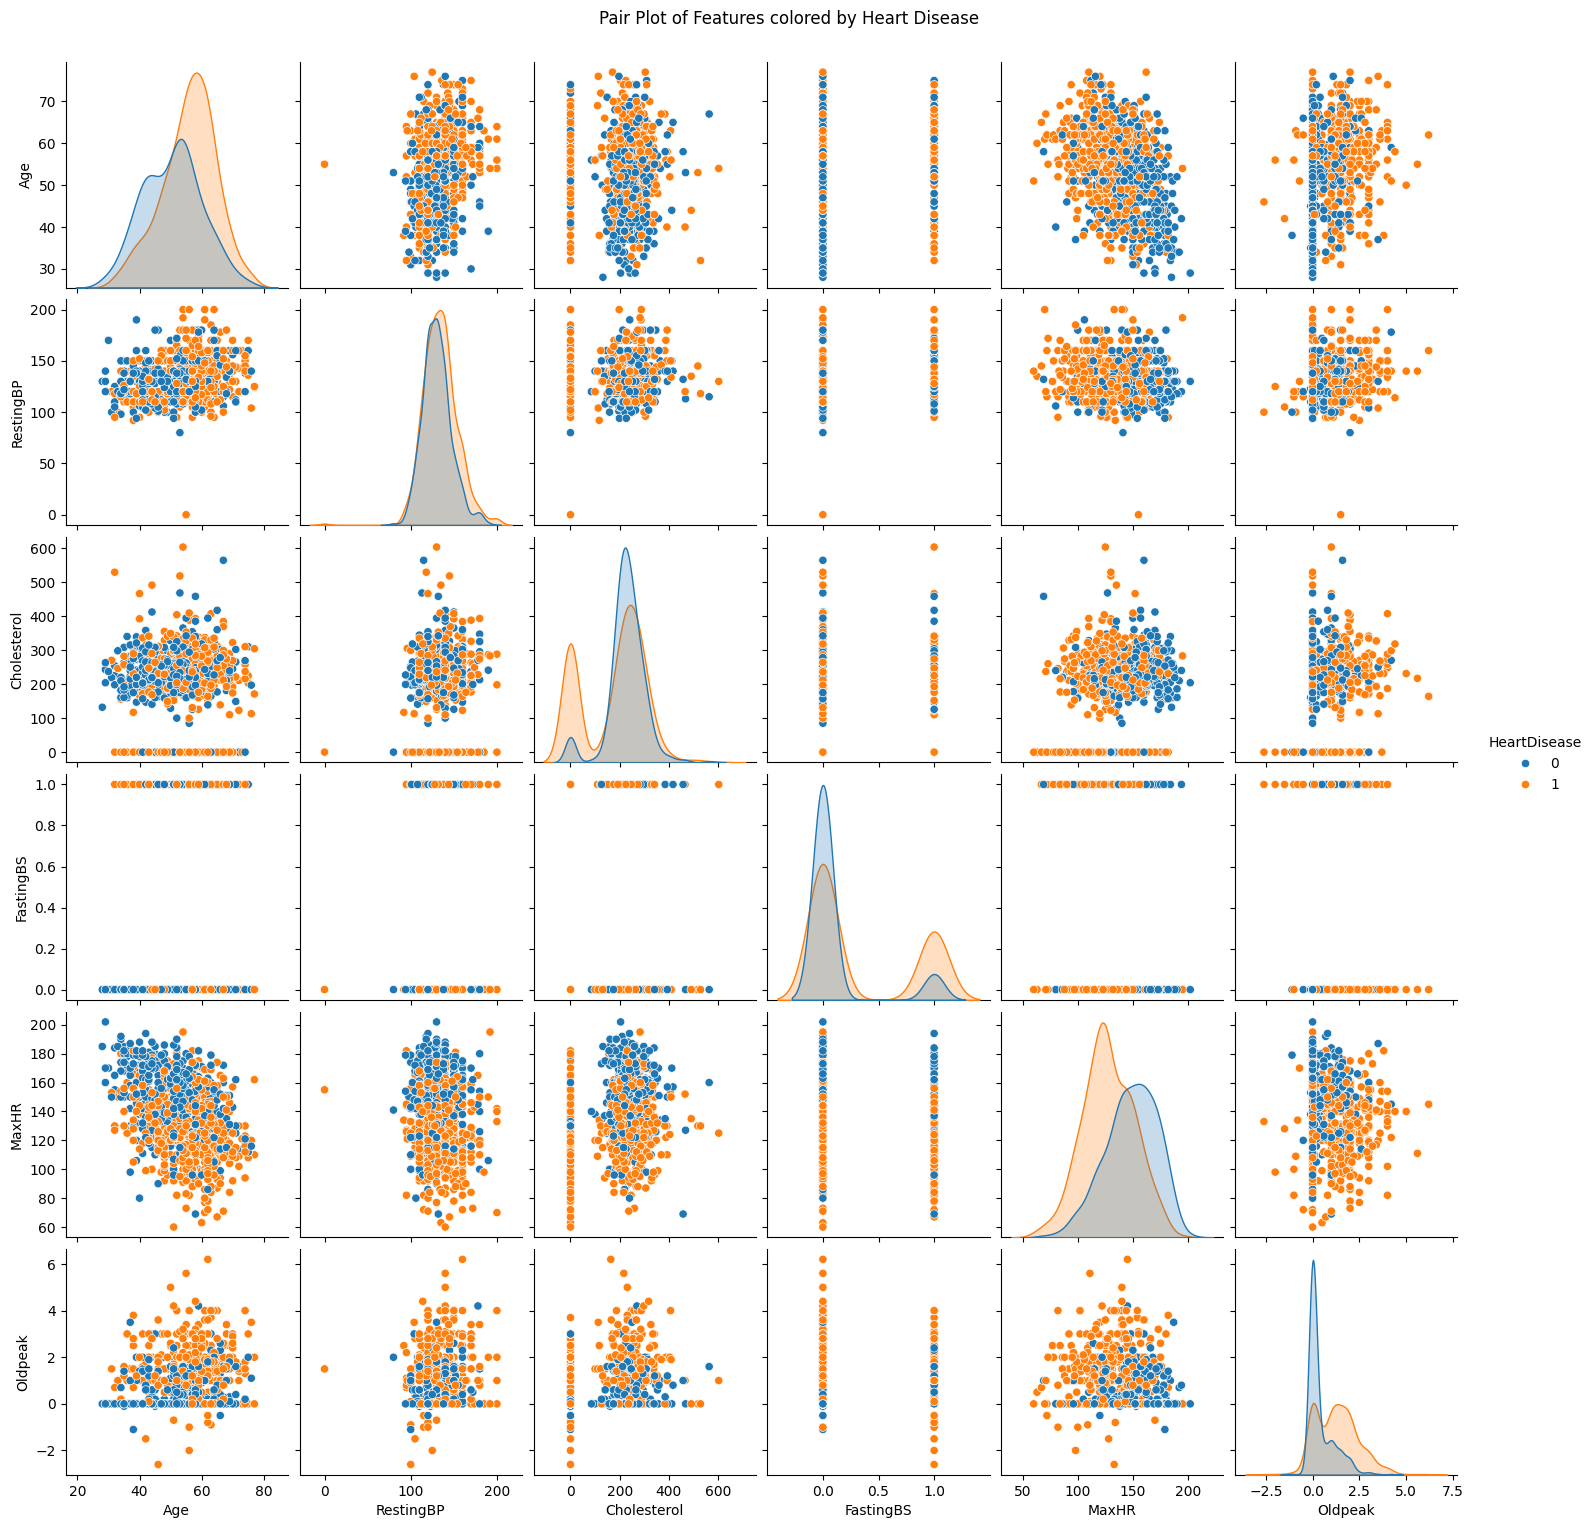

Pair plot generated.


In [11]:
print("Generating pair plot...")
sns.pairplot(df, hue='HeartDisease', diag_kind='kde')
plt.suptitle('Pair Plot of Features colored by Heart Disease', y=1.02) # Adjust suptitle to not overlap
plt.show()
print("Pair plot generated.")

In [7]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
# Separate features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (642, 15)
X_test shape: (276, 15)
y_train shape: (642,)
y_test shape: (276,)


In [9]:
# Initialize base classifiers
clf1 = RandomForestClassifier(random_state=42)
clf2 = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence
clf3 = SVC(probability=True, random_state=42)

# Create a VotingClassifier
eclf1 = VotingClassifier(estimators=[('rf', clf1), ('lr', clf2), ('svc', clf3)], voting='soft', weights=[1,1,1])

# Train the VotingClassifier
eclf1 = eclf1.fit(X_train, y_train)

print("VotingClassifier trained successfully.")

VotingClassifier trained successfully.


Ensemble Model Accuracy: 0.8986

Classification Report for Ensemble Model:

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       112
           1       0.93      0.90      0.91       164

    accuracy                           0.90       276
   macro avg       0.89      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276


Confusion Matrix for Ensemble Model:



array([[100,  12],
       [ 16, 148]])

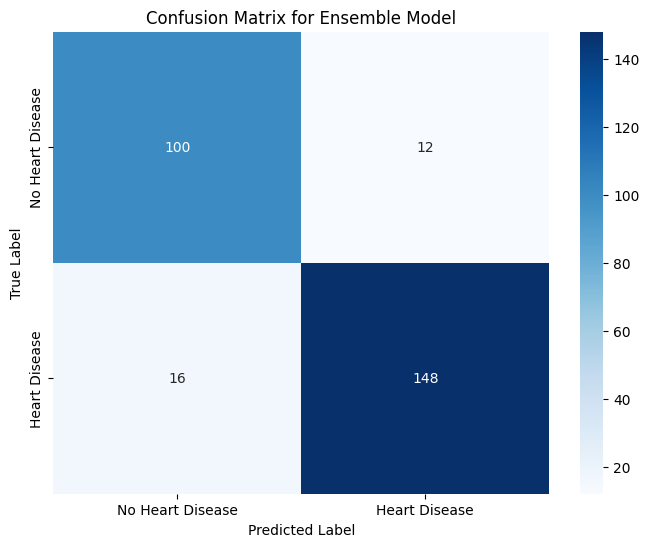

In [10]:
# Make predictions on the test set
y_pred_ensemble = eclf1.predict(X_test)

# Evaluate the ensemble model
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
report_ensemble = classification_report(y_test, y_pred_ensemble)
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)

print(f"Ensemble Model Accuracy: {accuracy_ensemble:.4f}")
print("\nClassification Report for Ensemble Model:\n")
print(report_ensemble)
print("\nConfusion Matrix for Ensemble Model:\n")
display(conf_matrix_ensemble)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Ensemble Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# after the hyper parameters tuning


In [12]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Define parameter grid for LogisticRegression
param_grid_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear', 'lbfgs']
}

# Define parameter grid for SVC
param_grid_svc = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf']
}

print("Parameter grids for base classifiers defined.")

Parameter grids for base classifiers defined.


In [13]:
# Initialize base classifiers again for hyperparameter tuning
clf1_tuned = RandomForestClassifier(random_state=42)
clf2_tuned = LogisticRegression(random_state=42, max_iter=1000)
clf3_tuned = SVC(probability=True, random_state=42)

# Define the VotingClassifier with named estimators for GridSearchCV
eclf_tuned = VotingClassifier(estimators=[('rf', clf1_tuned), ('lr', clf2_tuned), ('svc', clf3_tuned)], voting='soft')

# Define the full parameter grid for the VotingClassifier
# Prefix parameter names with the estimator name and two underscores (e.g., 'rf__n_estimators')
voting_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'lr__C': [0.1, 1.0],
    'lr__solver': ['liblinear'],
    'svc__C': [0.1, 1.0],
    'svc__kernel': ['rbf'],
    'weights': [[0.5, 0.5, 0.5], [1, 1, 1]]
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=eclf_tuned, param_grid=voting_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Hyperparameter tuning completed.


Best Parameters found: {'lr__C': 1.0, 'lr__solver': 'liblinear', 'rf__max_depth': 20, 'rf__n_estimators': 200, 'svc__C': 0.1, 'svc__kernel': 'rbf', 'weights': [0.5, 0.5, 0.5]}
Best Cross-Validation Accuracy: 0.8613

Best Ensemble Model Accuracy on Test Set: 0.8949

Classification Report for Best Ensemble Model:

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       112
           1       0.91      0.91      0.91       164

    accuracy                           0.89       276
   macro avg       0.89      0.89      0.89       276
weighted avg       0.90      0.89      0.90       276


Confusion Matrix for Best Ensemble Model:



array([[ 98,  14],
       [ 15, 149]])

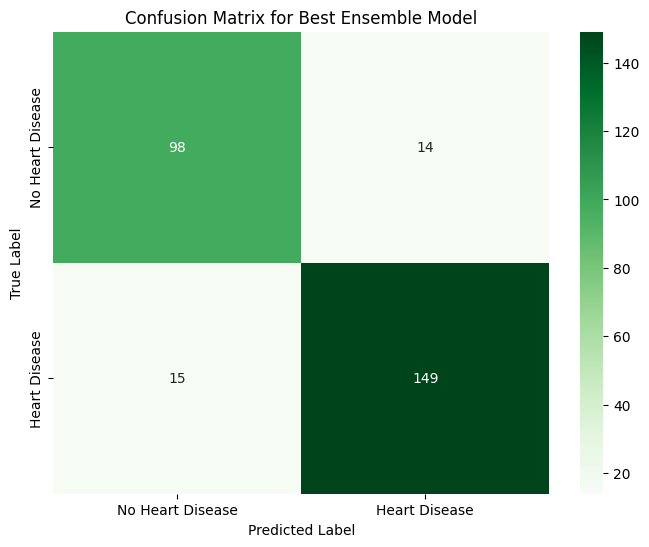

In [14]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

# Train the VotingClassifier with the best parameters
best_eclf = grid_search.best_estimator_
best_eclf.fit(X_train, y_train)

# Make predictions with the best ensemble model
y_pred_best_ensemble = best_eclf.predict(X_test)

# Evaluate the best ensemble model
accuracy_best_ensemble = accuracy_score(y_test, y_pred_best_ensemble)
report_best_ensemble = classification_report(y_test, y_pred_best_ensemble)
conf_matrix_best_ensemble = confusion_matrix(y_test, y_pred_best_ensemble)

print(f"\nBest Ensemble Model Accuracy on Test Set: {accuracy_best_ensemble:.4f}")
print("\nClassification Report for Best Ensemble Model:\n")
print(report_best_ensemble)
print("\nConfusion Matrix for Best Ensemble Model:\n")
display(conf_matrix_best_ensemble)

# Visualize the confusion matrix of the best model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_ensemble, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Best Ensemble Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
# Get the best Random Forest estimator from the VotingClassifier
rf_estimator = best_eclf.named_estimators_['rf']

# Get feature importances from the Random Forest model
feature_importances = rf_estimator.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from Random Forest:")
display(importance_df.head(10))

Top 10 Feature Importances from Random Forest:


,Feature,Importance
14,ST_Slope_Up,0.152534
5,Oldpeak,0.118668
13,ST_Slope_Flat,0.114322
4,MaxHR,0.111151
2,Cholesterol,0.098794
0,Age,0.095640
12,ExerciseAngina_Y,0.089405
1,RestingBP,0.073484
7,ChestPainType_ATA,0.036281
6,Sex_M,0.030419


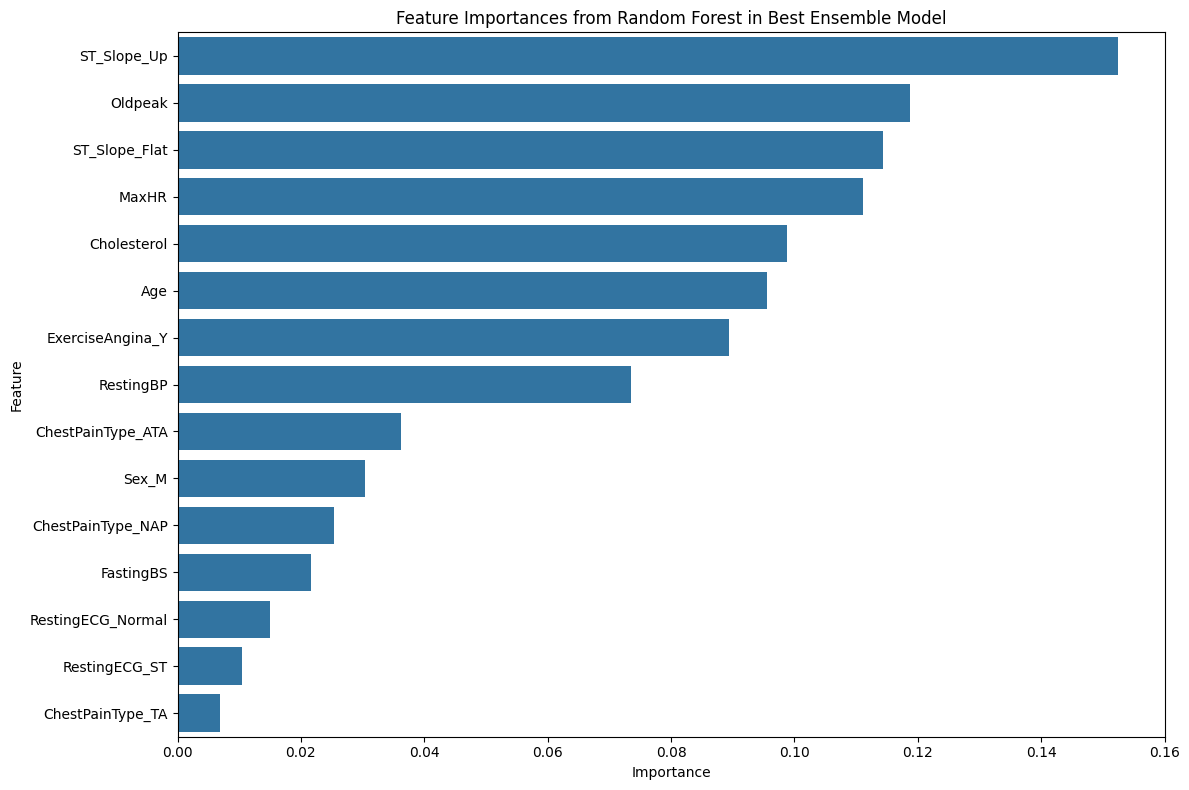

In [16]:
# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest in Best Ensemble Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Applying the voting regression on the same data set


VotingRegressor trained successfully.

Ensemble Regression Model (Binarized) Accuracy: 0.9058

Classification Report for Ensemble Regression Model (Binarized):

              precision    recall  f1-score   support

           0       0.86      0.91      0.89       112
           1       0.94      0.90      0.92       164

    accuracy                           0.91       276
   macro avg       0.90      0.91      0.90       276
weighted avg       0.91      0.91      0.91       276


Confusion Matrix for Ensemble Regression Model (Binarized):



array([[102,  10],
       [ 16, 148]])


Mean Squared Error (Continuous Predictions): 0.1082
R-squared (Continuous Predictions): 0.5512


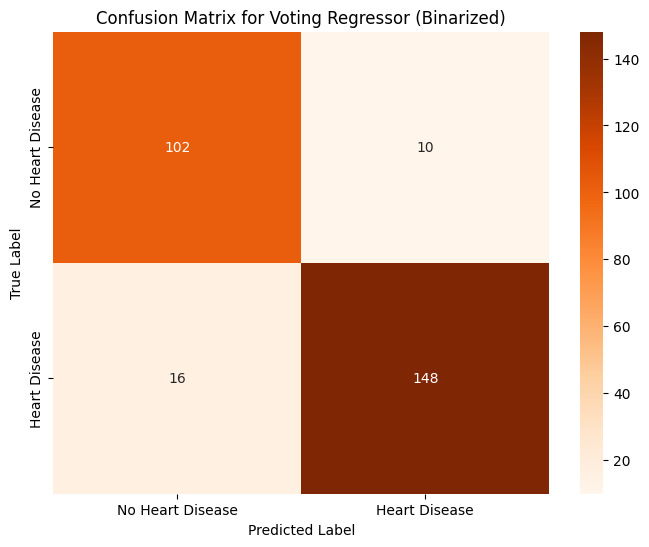

In [17]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Initialize base regressors
reg1 = RandomForestRegressor(random_state=42)
reg2 = LinearRegression()
reg3 = SVR()

# Create a VotingRegressor
eclf_reg = VotingRegressor(estimators=[('rf', reg1), ('lr', reg2), ('svc', reg3)], weights=[1,1,1])

# Train the VotingRegressor
eclf_reg = eclf_reg.fit(X_train, y_train)

print("VotingRegressor trained successfully.")

# Make continuous predictions on the test set
y_pred_regression_continuous = eclf_reg.predict(X_test)

# Binarize predictions for evaluation against binary target
y_pred_regression_binary = (y_pred_regression_continuous > 0.5).astype(int)

# Evaluate the ensemble regression model with classification metrics
accuracy_regression = accuracy_score(y_test, y_pred_regression_binary)
report_regression = classification_report(y_test, y_pred_regression_binary)
conf_matrix_regression = confusion_matrix(y_test, y_pred_regression_binary)

print(f"\nEnsemble Regression Model (Binarized) Accuracy: {accuracy_regression:.4f}")
print("\nClassification Report for Ensemble Regression Model (Binarized):\n")
print(report_regression)
print("\nConfusion Matrix for Ensemble Regression Model (Binarized):\n")
display(conf_matrix_regression)

# Optional: Also show regression metrics for continuous predictions
mse = mean_squared_error(y_test, y_pred_regression_continuous)
r2 = r2_score(y_test, y_pred_regression_continuous)
print(f"\nMean Squared Error (Continuous Predictions): {mse:.4f}")
print(f"R-squared (Continuous Predictions): {r2:.4f}")

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_regression, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Voting Regressor (Binarized)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#applying the hyper parameter tuning here


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Hyperparameter tuning for VotingRegressor completed.

Best Parameters found for VotingRegressor: {'lr__fit_intercept': False, 'rf__max_depth': 5, 'rf__n_estimators': 50, 'svc__C': 10.0, 'svc__kernel': 'rbf', 'weights': [0.5, 0.5, 0.5]}
Best Cross-Validation Negative Mean Squared Error: -0.1175

Best Ensemble Regression Model (Binarized) Accuracy on Test Set: 0.9022

Classification Report for Best Ensemble Regression Model (Binarized):

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       112
           1       0.93      0.91      0.92       164

    accuracy                           0.90       276
   macro avg       0.90      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276


Confusion Matrix for Best Ensemble Regression Model (Binarized):



array([[100,  12],
       [ 15, 149]])

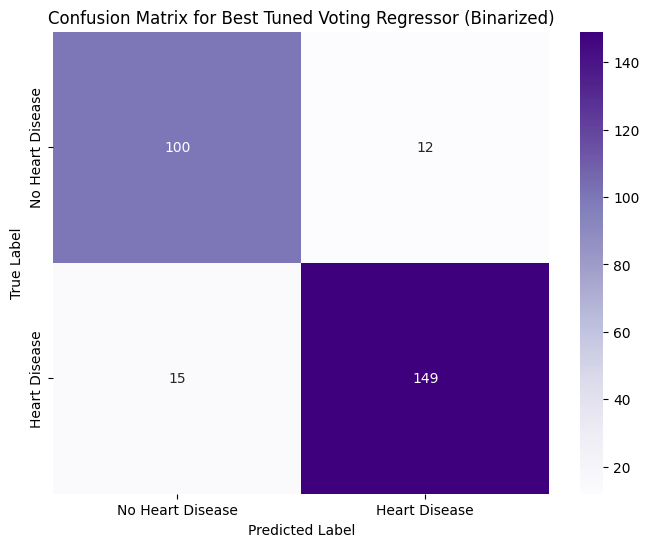

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize base regressors again for hyperparameter tuning
reg1_tuned = RandomForestRegressor(random_state=42)
reg2_tuned = LinearRegression()
reg3_tuned = SVR()

# Define the VotingRegressor with named estimators for GridSearchCV
eclf_reg_tuned = VotingRegressor(estimators=[('rf', reg1_tuned), ('lr', reg2_tuned), ('svc', reg3_tuned)])

# Define the full parameter grid for the VotingRegressor
# Prefix parameter names with the estimator name and two underscores (e.g., 'rf__n_estimators')
voting_reg_param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [5, 10],
    'lr__fit_intercept': [True, False],
    'svc__C': [0.1, 1.0, 10.0],
    'svc__kernel': ['rbf'], # Keep rbf for SVR generally good performance
    'weights': [[0.5, 0.5, 0.5], [1, 1, 1]]
}

# Perform GridSearchCV for the VotingRegressor
# Using 'neg_mean_squared_error' as scoring for regression models, then taking the best based on that.
# For binary classification evaluation, we'll binarize predictions later.
grid_search_reg = GridSearchCV(estimator=eclf_reg_tuned, param_grid=voting_reg_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search_reg.fit(X_train, y_train)

print("Hyperparameter tuning for VotingRegressor completed.")

# Get the best parameters and best score
best_params_reg = grid_search_reg.best_params_
best_score_reg = grid_search_reg.best_score_

print(f"\nBest Parameters found for VotingRegressor: {best_params_reg}")
print(f"Best Cross-Validation Negative Mean Squared Error: {best_score_reg:.4f}")

# Train the VotingRegressor with the best parameters
best_eclf_reg = grid_search_reg.best_estimator_
best_eclf_reg.fit(X_train, y_train)

# Make continuous predictions with the best ensemble regression model
y_pred_best_reg_continuous = best_eclf_reg.predict(X_test)

# Binarize predictions for evaluation against binary target
y_pred_best_reg_binary = (y_pred_best_reg_continuous > 0.5).astype(int)

# Evaluate the best ensemble regression model with classification metrics
accuracy_best_reg = accuracy_score(y_test, y_pred_best_reg_binary)
report_best_reg = classification_report(y_test, y_pred_best_reg_binary)
conf_matrix_best_reg = confusion_matrix(y_test, y_pred_best_reg_binary)

print(f"\nBest Ensemble Regression Model (Binarized) Accuracy on Test Set: {accuracy_best_reg:.4f}")
print("\nClassification Report for Best Ensemble Regression Model (Binarized):\n")
print(report_best_reg)
print("\nConfusion Matrix for Best Ensemble Regression Model (Binarized):\n")
display(conf_matrix_best_reg)

# Visualize the confusion matrix of the best regressor model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_reg, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Best Tuned Voting Regressor (Binarized)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()